In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.4/891.4 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 42.5 MB/s eta 0:00:00


In [3]:
 pip install reformer_pytorch==1.4.4

  Preparing metadata (setup.py) ... done
  Created wheel for axial-positional-embedding: filename=axial_positional_embedding-0.2.1-py3-none-any.whl size=2887 sha256=3c4e9bc7242cb4eae4c83adefc8cc86938631538e3f276bf75fa3468b480027d
  Stored in directory: /root/.cache/pip/wheels/b1/cb/39/7ce7ff2d2fd37cfe1fe7b3a3c43cf410632b2ad3b3f3986d73
Successfully built axial-positional-embedding


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
import matplotlib.pyplot as plt
import tensorflow as tf
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
import os
np.random.seed(42)


In [5]:
import pandas as pd

datos = pd.read_csv('/content/drive/MyDrive/Tesis/transformers/datosNarmax/24_pollution_itransformer.csv')

datos['date'] = pd.to_datetime(datos['date'])

# Se establece la columna date como index
datos.set_index('date', inplace=True)


In [6]:
datos.head()

,dew,temp,press,wnd_dir,wnd_spd,pollution,error
date,,,,,,,
2010-01-02 00:00:00,-1.214023,-1.268524,0.329687,-0.380944,-0.464048,0.317681,NaN
2010-01-02 01:00:00,-1.144302,-1.268524,0.329687,-0.380944,-0.446575,0.526152,NaN
2010-01-02 02:00:00,-0.865419,-1.349314,0.426127,-0.380944,-0.429103,0.646846,NaN
2010-01-02 03:00:00,-0.586536,-1.349314,0.522567,-0.380944,-0.393962,0.888234,NaN
2010-01-02 04:00:00,-0.586536,-1.349314,0.522567,-0.380944,-0.376489,0.416431,NaN


In [7]:
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe input es un tipo de dato: ", datos.index.dtype)


El index del dataframe input es un tipo de dato:  datetime64[ns]


In [8]:
datos['error'] = datos['error'].fillna(0)

In [9]:
datosNormalizados = datos

In [10]:
first_column = datosNormalizados.pop(datosNormalizados.columns[5])
datosNormalizados["pollution"] = first_column

In [11]:
datosNormalizados.head(10)

,dew,temp,press,wnd_dir,wnd_spd,error,pollution
date,,,,,,,
2010-01-02 00:00:00,-1.214023,-1.268524,0.329687,-0.380944,-0.464048,0.0,0.317681
2010-01-02 01:00:00,-1.144302,-1.268524,0.329687,-0.380944,-0.446575,0.0,0.526152
2010-01-02 02:00:00,-0.865419,-1.349314,0.426127,-0.380944,-0.429103,0.0,0.646846
2010-01-02 03:00:00,-0.586536,-1.349314,0.522567,-0.380944,-0.393962,0.0,0.888234
2010-01-02 04:00:00,-0.586536,-1.349314,0.522567,-0.380944,-0.376489,0.0,0.416431
2010-01-02 05:00:00,-0.586536,-1.430104,0.522567,-0.380944,-0.359017,0.0,0.098238
2010-01-02 06:00:00,-0.586536,-1.430104,0.619008,-0.380944,-0.323876,0.0,0.054349
2010-01-02 07:00:00,-0.586536,-1.349314,0.715448,-0.380944,-0.288735,0.0,0.262820
2010-01-02 08:00:00,-0.656257,-1.430104,0.715448,-0.380944,-0.253594,0.0,0.218931


In [12]:
target = "pollution"
futuros = 24
pasados = 12

In [13]:
df = datosNormalizados.reset_index()
df['target'] = df[target].shift(-futuros)

df = df.drop(df.tail(futuros-1).index)

df.tail(40)

,date,dew,temp,press,wnd_dir,wnd_spd,error,pollution,target
43737,2014-12-29 09:00:00,-0.795699,-1.106944,-0.248955,-1.456426,-0.464244,0.212208,0.449347,-0.922175
43738,2014-12-29 10:00:00,-0.865419,-0.702994,-0.248955,-1.456426,-0.446772,0.270611,0.350598,-0.823425
43739,2014-12-29 11:00:00,-0.865419,-0.541414,-0.248955,-1.456426,-0.429299,0.449112,0.372542,-0.571065
43740,2014-12-29 12:00:00,-0.935140,-0.218254,-0.345395,0.694538,-0.437741,-0.405326,-0.483288,-0.560093
43741,2014-12-29 13:00:00,-1.004861,-0.056674,-0.441835,0.694538,-0.297373,-0.394539,-0.571065,-0.296761
43742,2014-12-29 14:00:00,-1.074581,-0.056674,-0.538276,0.694538,-0.157004,-0.505426,-0.801481,-0.384538
43743,2014-12-29 15:00:00,-1.074581,-0.056674,-0.538276,0.694538,0.001032,-0.502256,-0.790508,-0.494260
43744,2014-12-29 16:00:00,-1.144302,-0.056674,-0.538276,0.694538,0.141401,-0.558037,-0.878286,-0.439399
43745,2014-12-29 17:00:00,-1.144302,-0.137464,-0.441835,0.694538,0.220321,-0.545485,-0.856341,-0.406482
43746,2014-12-29 18:00:00,-1.144302,-0.460624,-0.345395,-1.456426,-0.481717,0.531308,0.218931,-0.230928


Se vuelve a dividir el dataframe

In [14]:
# Dividir el conjunto de datos en entrenamiento y prueba
train, test = train_test_split(df, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
test, val = train_test_split(test, test_size=0.33, shuffle=False)

# Volver a dividir en conjunto de validación Narmax
test, test2 = train_test_split(test, test_size=0.3, shuffle=False)

print("Las dimensiones de train son: ", train.shape)
print("Las dimensiones de test son: ", test.shape)
print("Las dimensiones de val son: ", val.shape)

Las dimensiones de train son:  (30643, 9)
Las dimensiones de test son:  (6159, 9)
Las dimensiones de val son:  (4335, 9)


Se crea un dataloader modificado

In [15]:
!git clone https://github.com/thuml/Time-Series-Library.git

Cloning into 'Time-Series-Library'...
remote: Enumerating objects: 1828, done.
remote: Total 1828 (delta 0), reused 0 (delta 0), pack-reused 1828 (from 1)
Receiving objects: 100% (1828/1828), 78.19 MiB | 12.14 MiB/s, done.
Resolving deltas: 100% (1263/1263), done.


In [16]:
import sys
sys.path.append('Time-Series-Library')

In [17]:
from models import iTransformer
from utils.timefeatures import time_features

In [18]:
from torch.utils.data import Dataset


class datasetCustom(Dataset):
    def __init__(self, flag='train', size=None,
                 features='MS', target='OT', scale=False, timeenc=1, freq='h', seasonal_patterns=None, dataProc=None):
        # size [seq_len, label_len, pred_len]
        #self.args = args
        # info
        self.seq_len = size[0]
        self.label_len = size[1]
        self.pred_len = size[2]
        # init
        assert flag in ['train', 'test', 'val']
        type_map = {'train': 0, 'val': 1, 'test': 2}

        self.set_type = type_map[flag]

        self.features = features
        self.target = target
        #self.scale = scale
        self.timeenc = timeenc
        self.freq = freq

        #self.root_path = root_path
        self.dataProc = dataProc
        self.__read_data__()

    def __read_data__(self):
        #self.scaler = StandardScaler()
        df_raw = self.dataProc

        '''
        df_raw.columns: ['date', ...(other features), target feature]
        '''

        self.targetSet = df_raw[df_raw.columns[1:]].values
        cols = list(df_raw.columns)
        cols.remove("target")
        cols.remove('date')

        df_raw = df_raw[['date'] + cols] #+ ["target"]]

        '''
        num_train = int(len(df_raw) * 0.7)
        num_test = int(len(df_raw) * 0.2)
        num_vali = len(df_raw) - num_train - num_test
        border1s = [0, num_train - self.seq_len, len(df_raw) - num_test - self.seq_len]
        border2s = [num_train, num_train + num_vali, len(df_raw)]
        border1 = border1s[self.set_type]
        border2 = border2s[self.set_type]
        '''
        if self.features == 'M' or self.features == 'MS':
            cols_data = df_raw.columns[1:]
            df_data = df_raw[cols_data]
        elif self.features == 'S':
            df_data = df_raw[[self.target]]
        '''
        if self.scale:
            train_data = df_data[border1s[0]:border2s[0]]
            self.scaler.fit(train_data.values)
            data = self.scaler.transform(df_data.values)
        else:'''
        data = df_data.values

        df_stamp = df_raw[['date']]  #[border1:border2]
        df_stamp['date'] = pd.to_datetime(df_stamp.date)
        #print(type(df_stamp))
        if self.timeenc == 0:
            df_stamp['year'] = df_stamp.date.apply(lambda row: row.year, 1)
            df_stamp['month'] = df_stamp.date.apply(lambda row: row.month, 1)
            df_stamp['day'] = df_stamp.date.apply(lambda row: row.day, 1)
            df_stamp['hour'] = df_stamp.date.apply(lambda row: row.hour, 1)
            data_stamp = df_stamp.drop(['date'], axis=1).values
        elif self.timeenc == 1:
            data_stamp = time_features(pd.to_datetime(df_stamp['date'].values), freq=self.freq)
            data_stamp = data_stamp.transpose(1, 0)

        self.data_x = data
        self.data_y = data
        #print("dimensiones de x:", self.data_x.shape)
        #print("dimensiones de y:", self.data_y.shape)
        '''
        if self.set_type == 0 and self.args.augmentation_ratio > 0:
            self.data_x, self.data_y, augmentation_tags = run_augmentation_single(self.data_x, self.data_y, self.args)
        '''
        self.data_stamp = data_stamp

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end - self.label_len
        r_end = r_begin + self.label_len + self.pred_len

        seq_x = self.data_x[s_begin:s_end]
        seq_y = self.data_y[r_begin:r_end]
        #print("dimensiones de x en getItem:", seq_x.shape)
        #print("dimensiones de y en getItem:", seq_y.shape)
        seq_x_mark = self.data_stamp[s_begin:s_end]
        seq_y_mark = self.data_stamp[r_begin:r_end]
        seq_target = self.targetSet[r_begin:r_end]

        return seq_x, seq_y, seq_x_mark, seq_y_mark, seq_target

    def __len__(self):
        return len(self.data_x) - self.seq_len - self.pred_len + 1


In [19]:
features = 'MS'
target = 'pollution'
freq = 'H'

In [20]:
seq_len = 12 # input sequence length of Informer encoder
label_len = 12 # start token length of Informer decoder
pred_len = 1 # prediction sequence length
timeenc=0

In [21]:
from torch.utils.data import DataLoader

trainDataset = datasetCustom(
            size=[seq_len, label_len, pred_len],
            features=features,
            target=target,
            timeenc=timeenc,
            freq=freq,
            dataProc=test
        )
testDataset = datasetCustom(
            size=[seq_len, label_len, pred_len],
            features=features,
            target=target,
            timeenc=timeenc,
            freq=freq,
            dataProc=test2
        )
valDataset = datasetCustom(
            size=[seq_len, label_len, pred_len],
            features=features,
            target=target,
            timeenc=timeenc,
            freq=freq,
            dataProc=val
        )

<ipython-input-18-a9425b45dae7>:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stamp['date'] = pd.to_datetime(df_stamp.date)
<ipython-input-18-a9425b45dae7>:70: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  df_stamp['year'] = df_stamp.date.apply(lambda row: row.year, 1)
<ipython-input-18-a9425b45dae7>:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stamp['year'] = 

In [22]:
a = trainDataset.data_y
a

array([[ 1.43536459,  1.07438571, -1.88843959, ..., -0.437741  ,
         0.32305983,  0.61392965],
       [ 1.43536459,  0.99359571, -1.98487987, ..., -0.46404777,
        -0.23646875,  0.04337667],
       [ 1.43536459,  0.99359571, -1.98487987, ..., -0.42890663,
        -0.51961839, -0.05537288],
       ...,
       [-0.58653639, -0.86457415, -0.53827576, ..., -0.4817165 ,
         0.62077188, -0.07731722],
       [-0.79569856, -0.46062418, -0.53827576, ..., -0.49035455,
         0.89625293,  0.17504274],
       [-0.93514   , -0.29904419, -0.44183548, ..., -0.47288214,
         0.70208144, -0.01148419]])

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl

class InformerLightning(pl.LightningModule):
    def __init__(self, model, args):
        super(InformerLightning, self).__init__()
        self.model = model  
        self.args = args  # Argumentos como epochs
        self.train_losses = []
        self.val_losses = []

    def forward(self, batch_x, batch_x_mark, dec_inp, batch_y_mark):
        return self.model(batch_x, batch_x_mark, dec_inp, batch_y_mark)

    def training_step(self, batch, batch_idx):
        batch_x, batch_y, batch_x_mark, batch_y_mark, seq_target = batch
        batch_x = batch_x.float()
        batch_y = batch_y.float()
        batch_x_mark = batch_x_mark.float()
        batch_y_mark = batch_y_mark.float()
        seq_target = seq_target.float()

        # Input del decoder
        dec_inp = torch.zeros_like(batch_y[:, -self.args.pred_len:, :]).float()
        dec_inp = torch.cat([batch_y[:, :self.args.label_len, :], dec_inp], dim=1).float()

        # Forward pass
        outputs = self(batch_x, batch_x_mark, dec_inp, batch_y_mark)
        #print("shape de output: ", outputs.shape)
        f_dim = -1 if self.args.features == 'MS' else 0
        outputs = outputs[:, -self.args.pred_len, f_dim:]
        real = seq_target[:, -self.args.pred_len-1, f_dim:]
        loss = nn.MSELoss()(real, outputs)

        self.log('train_loss', value=loss)

        return loss

    def validation_step(self, batch, batch_idx):
        batch_x, batch_y, batch_x_mark, batch_y_mark, seq_target = batch
        batch_x = batch_x.float()
        batch_y = batch_y.float()
        batch_x_mark = batch_x_mark.float()
        batch_y_mark = batch_y_mark.float()
        seq_target = seq_target.float()

        # Input del decoder
        dec_inp = torch.zeros_like(batch_y[:, -self.args.pred_len:, :]).float()
        dec_inp = torch.cat([batch_y[:, :self.args.label_len, :], dec_inp], dim=1).float()

        # Forward pass
        outputs = self(batch_x, batch_x_mark, dec_inp, batch_y_mark)
        f_dim = -1 if self.args.features == 'MS' else 0
        outputs = outputs[:, -self.args.pred_len, f_dim:]
        real = seq_target[:, -self.args.pred_len-1, f_dim:]
        loss = nn.MSELoss()(real, outputs)

        self.log('val_loss', value=loss)
        return loss

    def configure_optimizers(self):
        optimizer = self._select_optimizer()
        return optimizer

    def _select_optimizer(self):
        return optim.Adam(self.parameters(), lr=float(self.args.learning_rate))


    @classmethod
    def load_from_checkpoint(cls, checkpoint_path, model, conf, *args, **kwargs):
        # Cargar el estado del modelo desde el checkpoint
        checkpoint = torch.load(checkpoint_path)
        # Crear una instancia del modelo
        instance = cls(model, args=conf, *args, **kwargs)
        instance.load_state_dict(checkpoint['state_dict'])
        return instance


In [24]:
entradas = 7
frecuencia = 'H'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
class Configs:
    def __init__(self, hyperparams):
        # Parámetros generales
        self.task_name = 'long_term_forecast'
        #self.enc_in = entradas
        #self.dec_in = entradas
        #self.c_out = 1
        self.seq_len = pasados  # entrada
        self.label_len = label_len  # Definir este valor antes
        self.pred_len = 1  # Longitud de la predicción

        # Hiperparámetros que vienen del espacio de búsqueda
        self.d_model = int(hyperparams['d_model'])
        self.d_ff = self.d_model * 4
        self.n_heads = int(hyperparams['heads'])
        self.e_layers = int(hyperparams['e_layers'])
        self.factor = 5
        self.dropout = float(hyperparams['dropout'])
        self.learning_rate = float(hyperparams['learning_rate'])

        # Parámetros fijos o ajustables
        self.embed = 'fixed'
        self.freq = frecuencia
        self.activation = hyperparams['activation']
        self.features = "MS"
        #self.distil = True
        self.task_name = 'long_term_forecast'



In [26]:
from pytorch_lightning.callbacks import Callback

class LossRecorder(Callback):
    def __init__(self):
        self.train_loss_history = []
        self.val_loss_history = []

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss_history.append(trainer.callback_metrics["train_loss"].item())
        self.val_loss_history.append(trainer.callback_metrics["val_loss"].item())

In [27]:
import pytorch_lightning as pl

# Fijar la semilla para la reproducibilidad
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [28]:
params = {'activation': 'gelu', 'batch': 256, 'd_model': 256, 'dropout': 0.0, 'e_layers': 4.0, 'heads': 4, 'learning_rate': 1.5910558296167704e-05}

early_stop_callback = EarlyStopping(
  monitor='val_loss',
  min_delta=0.00,
  patience=15,
  verbose=True,
  mode='min'
)

checkpoint_callback = ModelCheckpoint(
monitor='val_loss',
dirpath='checkpoints',
filename='best-checkpoint',
save_top_k=1,
mode='min',
)

loss_recorder = LossRecorder()

configs = Configs(params)


model = iTransformer.Model(configs)
itransformerModel = InformerLightning(model, configs)


train_loader = DataLoader(trainDataset, batch_size=256, shuffle=False)
val_loader = DataLoader(testDataset, batch_size=256, shuffle=False)


trainer = pl.Trainer(
    callbacks=[early_stop_callback, checkpoint_callback, loss_recorder],
    max_epochs=128,
    accelerator='gpu',
    enable_progress_bar=True,
    logger=False
)


trainer.fit(itransformerModel, train_loader, val_dataloaders=val_loader)

bestModel = InformerLightning.load_from_checkpoint(trainer.checkpoint_callback.best_model_path, model=model, conf=configs)



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type  | Params | Mode 
----------------------------------------
0 | model | Model | 3.2 M  | train
----------------------------------------
3.2 M     Trainable params
0         Non-trainable params
3.2 M     Total params
12.653    Total estimated model params size (MB)
60        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.656


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 15 records. Best score: 0.448. Signaling Trainer to stop.
<ipython-input-23-da93c9bcb55d>:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an is

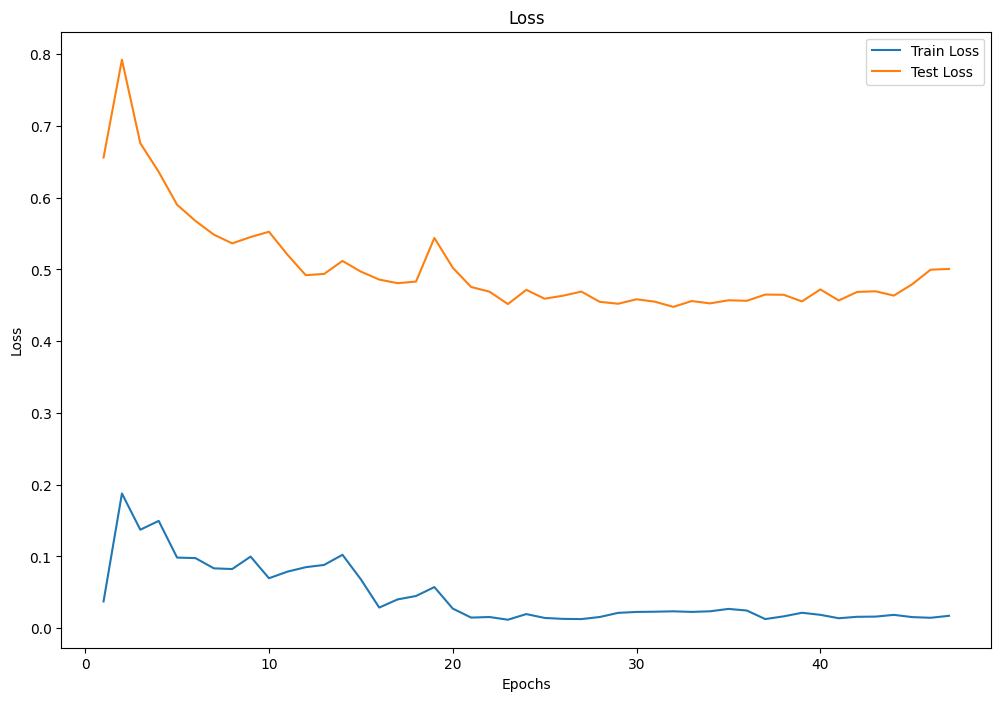

In [29]:
ejeCross = range(1, len(loss_recorder.train_loss_history) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeCross, loss_recorder.train_loss_history, label='Train Loss')
plt.plot(ejeCross, loss_recorder.val_loss_history, label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [30]:
from sklearn.metrics import mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [31]:
itransformerModel.eval()
preds = []
trues = []

test_loader = DataLoader(valDataset, batch_size=32, shuffle=False)

with torch.no_grad():
    for i, (batch_x, batch_y, batch_x_mark, batch_y_mark, seq_target) in enumerate(test_loader):
        batch_x = batch_x.float()
        batch_y = batch_y.float()
        batch_x_mark = batch_x_mark.float()
        batch_y_mark = batch_y_mark.float()
        seq_target = seq_target.float()


        dec_inp = torch.zeros_like(batch_y[:, -configs.pred_len:, :]).float()
        dec_inp = torch.cat([batch_y[:, :configs.label_len, :], dec_inp], dim=1).float().to(device)

        outputs = bestModel(batch_x, batch_x_mark, dec_inp, batch_y_mark)
        outputs = outputs[:, -configs.pred_len, -1:]
        batch_y = seq_target[:, -configs.pred_len-1, -1:]


        preds.append(outputs)
        trues.append(batch_y)

preds = np.concatenate(preds, axis=0)
trues = np.concatenate(trues, axis=0)

preds = preds.reshape(-1, preds.shape[-1])
trues = trues.reshape(-1, trues.shape[-1])

In [32]:
print(len(preds))
print(len(trues))

4323
4323


In [33]:
trues[-1]

array([-0.9660632], dtype=float32)

In [34]:
datosNormalizados.tail(2)

,dew,temp,press,wnd_dir,wnd_spd,error,pollution
date,,,,,,,
2014-12-31 22:00:00,-1.632347,-1.268524,1.679851,0.694538,4.344399,-0.426489,-1.009952
2014-12-31 23:00:00,-1.562627,-1.187734,1.679851,0.694538,4.405847,-0.342587,-0.966063


In [35]:
val.head(1)

,date,dew,temp,press,wnd_dir,wnd_spd,error,pollution,target
39442,2014-07-03 10:00:00,1.435365,1.155176,-1.406238,-0.380944,-0.323483,2.193202,1.941563,0.581013


In [36]:
preds[0]

array([0.8556096], dtype=float32)

In [37]:
trues[0]

array([0.7894844], dtype=float32)

In [38]:
val.head(40)

,date,dew,temp,press,wnd_dir,wnd_spd,error,pollution,target
39442,2014-07-03 10:00:00,1.435365,1.155176,-1.406238,-0.380944,-0.323483,2.193202,1.941563,0.581013
39443,2014-07-03 11:00:00,1.435365,1.235966,-1.502678,-0.380944,-0.288342,2.109410,1.908646,0.493236
39444,2014-07-03 12:00:00,1.435365,1.316756,-1.502678,-1.456426,-0.464048,1.928679,1.711147,0.570041
39445,2014-07-03 13:00:00,1.435365,1.316756,-1.502678,-0.380944,-0.464048,1.544705,1.447815,0.405458
39446,2014-07-03 14:00:00,1.435365,1.316756,-1.599119,-0.380944,-0.428907,1.271825,1.228371,0.405458
39447,2014-07-03 15:00:00,1.435365,1.397546,-1.695559,-0.380944,-0.393765,0.865525,0.844345,0.427403
39448,2014-07-03 16:00:00,1.435365,1.478336,-1.599119,-0.380944,-0.332318,0.808915,0.822401,0.855317
39449,2014-07-03 17:00:00,1.435365,1.397546,-1.599119,-0.380944,-0.297176,0.710639,0.734624,1.096705
39450,2014-07-03 18:00:00,1.435365,1.397546,-1.599119,-0.380944,-0.235729,0.627963,0.668791,1.239343
39451,2014-07-03 19:00:00,1.505085,1.316756,-1.502678,-0.380944,-0.200587,0.455294,0.548097,0.526152


In [39]:
# Calcular MSE
mse = mean_squared_error(trues, preds)

# Calcular RMSE
rmse_value = rmse(trues, preds)

# Calcular MAE
mae = mean_absolute_error(trues, preds)

smape_value = smape(trues, preds)

ia_value = ia(trues, preds)


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.8767877817153931
RMSE: 0.9363694787025452
MAE: 0.7011299133300781
SMAPE: 1.2614136934280396
IA: 0.32665592432022095


In [40]:
from datetime import timedelta

# Fecha y hora de término del conjunto de datos de prueba
end_date = datosNormalizados.index[-1]
n_observations = len(val)
# Calcular la fecha y hora de inicio
start_date = end_date - timedelta(minutes=10 * (n_observations - 1))
print(start_date)
print(end_date)
# Crear la serie de fechas y horas
val_date = pd.date_range(start=start_date, end=end_date, freq='10min')

val_date = val_date[pasados:]

2014-12-01 20:40:00
2014-12-31 23:00:00


In [41]:
print(val_date[0])

2014-12-01 22:40:00


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

df = pd.DataFrame({'Originales': trues.flatten(), 'Predichos': preds.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))

fig.show()

In [43]:
df.to_csv("/content/drive/MyDrive/Tesis/transformers/errores/narmax/24paso/itransformerPollution.csv", index=True)

In [44]:
model_save_path = '/content/drive/My Drive/Tesis/transformers/modelosEntrenados/NARMAX/24_pollution_itransformer.pt'
torch.save(itransformerModel.state_dict(), model_save_path)